# GNN Validation Experiment — Plug-and-Play Architecture Testing

**Goal:** Verify that each GNN architecture (a) converges and (b) actually exploits the EU trade network topology, rather than just memorising node features.

## Pipeline overview
| Stage | Description |
|---|---|
| **Data** | Same cleaned CSVs as before — no imputation needed |
| **Stability setup** | `log1p / 25.0` target scaling · manual self-loops · gradient clipping |
| **Model** | `PlugAndPlayGNN`: Linear encoder → 2-layer GNN backbone → link-predictor MLP |
| **Phase 1a Stability test** | 50 epochs, fixed LR — loss must decrease, predictions must not collapse |
| **Phase 1b Topology test** | Same model trained on shuffled edge_index — real graph must beat shuffled |
| **Sweep** | `[GCNConv, GATv2Conv, SAGEConv, TransformerConv]` |


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell A — Imports & Configuration
# ══════════════════════════════════════════════════════════════════════════════

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

try:
    from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv
    HAS_PYG = True
    print("✓ PyTorch Geometric available")
except ImportError:
    HAS_PYG = False
    print("✗ PyTorch Geometric not found — run: pip install torch-geometric")

warnings.filterwarnings("ignore", category=UserWarning)

# ── Canonical configuration (must match the pipeline) ─────────────────────────
START_MONTH = "2014-01"
END_MONTH   = "2025-11"
MONTHLY_IDX = pd.date_range(START_MONTH, END_MONTH, freq="MS")

COUNTRIES = [
    "AT", "BE", "BG", "CY", "CZ", "DE", "DK", "EE", "EL",
    "ES", "FI", "FR", "HR", "HU", "IE", "IT", "LT", "LU",
    "LV", "MT", "NL", "PL", "PT", "RO", "SE", "SI", "SK",
]
COUNTRY_IDX = {c: i for i, c in enumerate(COUNTRIES)}
N = len(COUNTRIES)   # 27

ALL_CATS = [
    "TOTAL", "Food_drinks_tobacco", "Raw_materials",
    "Energy", "Chemicals", "Machinery_vehicles", "Other_manufactured",
]
N_CATS = len(ALL_CATS)   # 7

CEPII_COLS = ["comlang_ethno", "contig", "smctry", "dist", "distcap", "distw", "distwces"]

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR      = Path("C:/Users/diede/Downloads/FILES FROM FULL DATA PIPELINE RUN")
MAIN_DATA_DIR = DATA_DIR / "main_data"
NODE_DIR      = DATA_DIR / "NodeFeatures" / "Second Try"
EDGE_DIR      = DATA_DIR / "edge_features"
GRAPH_DIR     = DATA_DIR / "graph_features"
IMPUTED_TRADE_CSV = MAIN_DATA_DIR / "eu_intra_trade_sitc_imputed.csv"

# ── Experiment hyperparameters ────────────────────────────────────────────────
HIDDEN_DIM   = 64      # H: node embedding dimension
N_EPOCHS     = 50      # epochs per validation run
LR           = 3e-4    # fixed learning rate (no scheduler — easier to compare)
GRAD_CLIP    = 1.0     # gradient norm cap → stabilises GATv2 / TransformerConv early steps
TARGET_SCALE = 25.0    # divide log1p trade values by this → MSE roughly in 0-1 range
HEADS        = 4       # attention heads for edge-aware architectures
SEED         = 42

TRAIN_END = pd.Timestamp("2022-12-01")
VAL_END   = pd.Timestamp("2023-12-01")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device       : {DEVICE}")
print(f"Monthly index: {MONTHLY_IDX[0].date()} → {MONTHLY_IDX[-1].date()} ({len(MONTHLY_IDX)} periods)")
print(f"Countries    : {N}  |  Categories: {N_CATS}  |  Directed edges: {N*(N-1)}")
print(f"Target scale : log1p / {TARGET_SCALE}")

c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 

✓ PyTorch Geometric available
Device       : cpu
Monthly index: 2014-01-01 → 2025-11-01 (143 periods)
Countries    : 27  |  Categories: 7  |  Directed edges: 702
Target scale : log1p / 25.0


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell B — Load All CSVs
# Data is already fully clean — no imputation needed.
# ══════════════════════════════════════════════════════════════════════════════

# ── B.1 Trade CSV ─────────────────────────────────────────────────────────────
df_trade = pd.read_csv(IMPUTED_TRADE_CSV)
df_trade["time"] = pd.to_datetime(df_trade["time"])
print(f"── Trade CSV ──")
print(f"  Shape      : {df_trade.shape}")
print(f"  Time range : {df_trade['time'].min().date()} → {df_trade['time'].max().date()}")
print(f"  Reporters  : {sorted(df_trade['reporter'].unique())}")
assert df_trade.isna().sum().sum() == 0, "NaNs in trade CSV!"
print(f"  NaNs       : 0 ✓\n")

# ── B.2 Node feature CSVs (T × 27 each) ──────────────────────────────────────
node_csv_paths = sorted(NODE_DIR.glob("*.csv"))
assert node_csv_paths, f"No node CSVs found in {NODE_DIR}"

node_dfs = {}   # stem → DataFrame(T, 27)
for p in node_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    node_dfs[p.stem] = df

total_node_nans = sum(df.isna().sum().sum() for df in node_dfs.values())
print(f"── Node feature CSVs ──")
print(f"  Files loaded : {len(node_dfs)}")
print(f"  Total NaNs   : {total_node_nans}")
assert total_node_nans == 0, f"Found {total_node_nans} NaNs in node features!"
print(f"  ✓ All clean\n")

# ── B.3 Graph feature CSVs (EURIBOR, VSTOXX — broadcast to all 27 cols) ──────
graph_csv_paths = sorted(GRAPH_DIR.glob("*.csv"))
graph_series = {}   # stem → Series(T,)

for p in graph_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    assert df.std(axis=1).max() < 1e-9, f"{p.name}: columns are not identical broadcasts!"
    graph_series[p.stem] = df.iloc[:, 0].rename(p.stem)

print(f"── Graph feature CSVs ──")
print(f"  Files loaded : {len(graph_series)}  → {list(graph_series.keys())}\n")

# ── B.4 Edge feature CSV (CEPII bilateral static) ─────────────────────────────
edge_csv = EDGE_DIR / "eu27_bilateral_static_features.csv"
assert edge_csv.exists(), f"Edge feature CSV not found at {edge_csv}"
df_edge = pd.read_csv(edge_csv)
df_edge["time"] = pd.to_datetime(df_edge["time"])
print(f"── Edge feature CSV ──")
print(f"  Shape  : {df_edge.shape}")
print(f"  Cols   : {list(df_edge.columns)}")

── Trade CSV ──
  Shape      : (100262, 10)
  Time range : 2014-01-01 → 2025-11-01
  Reporters  : ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
  NaNs       : 0 ✓

── Node feature CSVs ──
  Files loaded : 35
  Total NaNs   : 0
  ✓ All clean

── Graph feature CSVs ──
  Files loaded : 2  → ['euribor3m_monthly', 'vstoxx_monthly']

── Edge feature CSV ──
  Shape  : (100386, 11)
  Cols   : ['Unnamed: 0', 'time', 'reporter', 'partner', 'comlang_ethno', 'contig', 'smctry', 'dist', 'distcap', 'distw', 'distwces']


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell C — Tensor Assembly
# ══════════════════════════════════════════════════════════════════════════════

# ── C.1 Align all sources to a common monthly index ───────────────────────────
common_time = MONTHLY_IDX
for stem, df in node_dfs.items():
    common_time = common_time.intersection(df.index)
for stem, s in graph_series.items():
    common_time = common_time.intersection(s.index)
trade_times = pd.DatetimeIndex(sorted(df_trade["time"].unique()))
common_time = common_time.intersection(trade_times)
T = len(common_time)
print(f"Common time range: {common_time[0].date()} → {common_time[-1].date()}  (T={T})")

# ── C.2 Node feature tensor (T, N, F_node) ────────────────────────────────────
node_arrays, node_feat_names = [], []
for stem, df in sorted(node_dfs.items()):
    arr = df.loc[common_time, COUNTRIES].values.astype(np.float32)   # (T, N)
    node_arrays.append(arr)
    node_feat_names.append(stem)
node_np = np.stack(node_arrays, axis=-1)   # (T, N, F_node)
F_node  = node_np.shape[2]

# ── C.3 Graph feature tensor → broadcast to all nodes ────────────────────────
graph_feat_names = sorted(graph_series.keys())
graph_np = np.stack(
    [graph_series[s].reindex(common_time).values.astype(np.float32) for s in graph_feat_names],
    axis=-1,
)   # (T, F_graph)
graph_broadcast    = np.repeat(graph_np[:, np.newaxis, :], N, axis=1)    # (T, N, F_graph)
node_plus_graph_np = np.concatenate([node_np, graph_broadcast], axis=-1)  # (T, N, F_total)
F_total = node_plus_graph_np.shape[2]

# ── C.4 Target tensor (T, E, C) ───────────────────────────────────────────────
edge_pairs = [(i, j) for i in range(N) for j in range(N) if i != j]   # 702 directed edges
E      = len(edge_pairs)
src_idx = [p[0] for p in edge_pairs]
dst_idx = [p[1] for p in edge_pairs]

target_np = np.full((T, N, N, N_CATS), np.nan, dtype=np.float32)
for t_idx, ts in enumerate(common_time):
    df_t = df_trade[df_trade["time"] == ts]
    for _, row in df_t.iterrows():
        ri = COUNTRY_IDX.get(row["reporter"])
        pi = COUNTRY_IDX.get(row["partner"])
        if ri is not None and pi is not None and ri != pi:
            target_np[t_idx, ri, pi, :] = [row[c] for c in ALL_CATS]

target_edge_np = target_np[:, src_idx, dst_idx, :]   # (T, E, C)

# ── C.5 Static edge features (E, F_edge) ──────────────────────────────────────
F_edge = len(CEPII_COLS)
df_edge_t0   = df_edge[df_edge["time"] == df_edge["time"].min()].copy()
edge_feat_map = {}
for _, row in df_edge_t0.iterrows():
    ri = COUNTRY_IDX.get(row["reporter"])
    pi = COUNTRY_IDX.get(row["partner"])
    if ri is not None and pi is not None and ri != pi:
        edge_feat_map[(ri, pi)] = [row[c] for c in CEPII_COLS]

edge_feat_np = np.zeros((E, F_edge), dtype=np.float32)
for e_idx, (i, j) in enumerate(edge_pairs):
    if (i, j) in edge_feat_map:
        edge_feat_np[e_idx] = edge_feat_map[(i, j)]

# ── C.6 Convert to tensors ────────────────────────────────────────────────────
node_feat_tensor = torch.tensor(node_plus_graph_np, dtype=torch.float32)   # (T, N, F_total)
edge_feat_tensor = torch.tensor(edge_feat_np,       dtype=torch.float32)   # (E, F_edge)
target_tensor    = torch.tensor(target_edge_np,     dtype=torch.float32)   # (T, E, C)

print(f"\n✓ Tensor assembly complete")
print(f"  node_feat_tensor : {node_feat_tensor.shape}  (T, N, F_total={F_total})")
print(f"  edge_feat_tensor : {edge_feat_tensor.shape}  (E={E}, F_edge={F_edge})")
print(f"  target_tensor    : {target_tensor.shape}  (T, E, C={N_CATS})")
print(f"  NaNs in node features: {torch.isnan(node_feat_tensor).sum().item()}")
print(f"  NaNs in targets      : {torch.isnan(target_tensor).sum().item()}")

Common time range: 2014-01-01 → 2025-11-01  (T=143)

✓ Tensor assembly complete
  node_feat_tensor : torch.Size([143, 27, 37])  (T, N, F_total=37)
  edge_feat_tensor : torch.Size([702, 7])  (E=702, F_edge=7)
  target_tensor    : torch.Size([143, 702, 7])  (T, E, C=7)
  NaNs in node features: 0
  NaNs in targets      : 868


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell D — Temporal Split + Normalization
# ══════════════════════════════════════════════════════════════════════════════

# ── D.1 Strict temporal split ─────────────────────────────────────────────────
# t is the INPUT step; target is at t+1 → valid range: t in [0, T-2]
train_idx = [t for t, ts in enumerate(common_time[:-1]) if ts <= TRAIN_END]
val_idx   = [t for t, ts in enumerate(common_time[:-1]) if TRAIN_END < ts <= VAL_END]
test_idx  = [t for t, ts in enumerate(common_time[:-1]) if ts > VAL_END]

print("=== Temporal Split ===")
print(f"Train : {len(train_idx):3d} steps  ({common_time[train_idx[0]].date()} → {common_time[train_idx[-1]].date()})")
print(f"Val   : {len(val_idx):3d} steps  ({common_time[val_idx[0]].date()} → {common_time[val_idx[-1]].date()})")
print(f"Test  : {len(test_idx):3d} steps  ({common_time[test_idx[0]].date()} → {common_time[test_idx[-1]].date()})")

# ── D.2 Node feature normalization (z-score, train-set statistics only) ────────
train_node = node_feat_tensor[train_idx]                       # (T_train, N, F)
feat_mean  = train_node.reshape(-1, F_total).mean(dim=0)       # (F,)
feat_std   = train_node.reshape(-1, F_total).std(dim=0).clamp(min=1e-8)
node_feat_norm = (node_feat_tensor - feat_mean) / feat_std     # (T, N, F)

# ── D.3 Edge feature normalization (min-max → [0, 1]) ────────────────────────
edge_feat_min   = edge_feat_tensor.min(dim=0).values
edge_feat_max   = edge_feat_tensor.max(dim=0).values
edge_feat_range = (edge_feat_max - edge_feat_min).clamp(min=1e-8)
edge_feat_norm  = (edge_feat_tensor - edge_feat_min) / edge_feat_range   # (E, F_edge)

# ── D.4 Target: log1p → scale by TARGET_SCALE ────────────────────────────────
# log1p compresses heavy-tailed EUR flows.
# Dividing by TARGET_SCALE (≈ max realistic log value) brings MSE into ~0-1.
# At evaluation time: pred_EUR = expm1(pred_scaled * TARGET_SCALE).
target_log    = torch.log1p(target_tensor.clamp(min=0))   # (T, E, C)
target_scaled = target_log / TARGET_SCALE                  # (T, E, C)

valid_vals = target_scaled[~torch.isnan(target_scaled)]
print(f"\nTarget stats after log1p / {TARGET_SCALE}:")
print(f"  Mean   : {valid_vals.mean():.4f}")
print(f"  Std    : {valid_vals.std():.4f}")
print(f"  Min    : {valid_vals.min():.4f}")
print(f"  Max    : {valid_vals.max():.4f}")
print("\n✓ Normalization complete")

=== Temporal Split ===
Train : 108 steps  (2014-01-01 → 2022-12-01)
Val   :  12 steps  (2023-01-01 → 2023-12-01)
Test  :  22 steps  (2024-01-01 → 2025-10-01)

Target stats after log1p / 25.0:
  Mean   : 0.5961
  Std    : 0.1683
  Min    : 0.0000
  Max    : 0.9548

✓ Normalization complete


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell E — Stability Setup: Self-Loops & Shuffled Topology
# ══════════════════════════════════════════════════════════════════════════════

# ── E.1 Prediction edge_index — 702 directed edges, NO self-loops ─────────────
# This is used ONLY by the link predictor head (we never predict i→i trade).
edge_index_pred = torch.tensor(
    [[i for i, j in edge_pairs], [j for i, j in edge_pairs]],
    dtype=torch.long,
)   # (2, 702)

# ── E.2 Message-passing edge_index WITH self-loops ───────────────────────────
# Self-loops guarantee that even a poorly-initialised GNN layer can always
# "see" the node's own economic features, preventing dead embeddings early on.
self_loop_nodes = torch.arange(N, dtype=torch.long)
self_loop_ei    = torch.stack([self_loop_nodes, self_loop_nodes], dim=0)   # (2, N)
edge_index_mp   = torch.cat([edge_index_pred, self_loop_ei], dim=1)        # (2, 702+27)

# ── E.3 Edge features for message-passing ────────────────────────────────────
# Edge-aware architectures (GATv2, TransformerConv) need edge_attr for all MP edges.
# Self-loop entries get zero features — neutral signal.
self_loop_feat = torch.zeros(N, F_edge)
edge_feat_mp   = torch.cat([edge_feat_norm, self_loop_feat], dim=0)   # (729, F_edge)

# ── E.4 Shuffled message-passing edge_index — for the topology test ───────────
# Strategy: randomly reassign each destination index in edge_index_mp.
# This preserves the number of edges and (roughly) degree distribution,
# but destroys the true neighborhood structure — node i now aggregates messages
# from random nodes instead of its real EU trade partners.
# A model that truly exploits the trade network must score better on the
# real graph than on this shuffled version.
torch.manual_seed(SEED)
dst_perm       = torch.randperm(edge_index_mp.shape[1])
shuffled_ei_mp = torch.stack(
    [edge_index_mp[0], edge_index_mp[1, dst_perm]],
    dim=0,
)   # (2, 729) — same sources, randomised destinations
shuffled_ea_mp = edge_feat_mp[dst_perm]   # edge attr follows the permuted columns

print(f"edge_index_pred (prediction, no self-loops) : {edge_index_pred.shape}")
print(f"edge_index_mp   (message-passing + loops)   : {edge_index_mp.shape}")
print(f"edge_feat_mp                                : {edge_feat_mp.shape}")
print(f"Self-loops in edge_index_mp                 : {(edge_index_mp[0] == edge_index_mp[1]).sum().item()}")
print(f"Self-loops surviving the shuffle            : {(shuffled_ei_mp[0] == shuffled_ei_mp[1]).sum().item()}")
print("\n✓ Stability setup complete")

edge_index_pred (prediction, no self-loops) : torch.Size([2, 702])
edge_index_mp   (message-passing + loops)   : torch.Size([2, 729])
edge_feat_mp                                : torch.Size([729, 7])
Self-loops in edge_index_mp                 : 27
Self-loops surviving the shuffle            : 34

✓ Stability setup complete


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell F — PlugAndPlayGNN: Architecture-Agnostic Encoder-Decoder
# ══════════════════════════════════════════════════════════════════════════════

# Architectures that accept edge_attr inside the message-passing step
EDGE_AWARE_CONVS = {GATv2Conv, TransformerConv} if HAS_PYG else set()


def _build_conv_layer(conv_cls, H):
    """
    Instantiate one GNN conv layer of the chosen class.

    • GATv2Conv / TransformerConv  → multi-head, concat=True, edge_dim=F_edge
      Output per head = H // HEADS, concat → H.
    • GCNConv                      → add_self_loops=False (we add them manually)
    • SAGEConv                     → mean aggregation, standard H → H
    """
    if conv_cls in EDGE_AWARE_CONVS:
        return conv_cls(
            H, H // HEADS,
            heads    = HEADS,
            edge_dim = F_edge,
            concat   = True,
        )
    elif conv_cls is GCNConv:
        return conv_cls(H, H, add_self_loops=False)
    else:   # SAGEConv (and any future addition)
        return conv_cls(H, H)


class PlugAndPlayGNN(nn.Module):
    """
    Architecture-agnostic GNN for EU bilateral trade flow prediction.

    The backbone (conv_cls) is the only thing that changes between runs.
    Everything else — encoder, decoder, training loop — stays constant.

    Architecture
    ────────────
    1. Encoder      : Linear(F_in → H) + ReLU
       Projects the 37 economic features into a fixed-size embedding space.

    2. GNN Backbone : 2 × conv_cls(H → H)
       Message-passing over edge_index_mp (702 trade edges + 27 self-loops).
       BatchNorm + ReLU + Dropout after each layer.

    3. Link Predictor (Decoder) : MLP([h_u || h_v || e_uv] → N_CATS)
       Concatenates source embedding, destination embedding, and CEPII
       bilateral edge features, then predicts scaled log-trade-flows.

    Args
    ────
    conv_cls     : PyG conv class — GCNConv | GATv2Conv | SAGEConv | TransformerConv
    in_channels  : F_total (37 node features)
    hidden_dim   : H (default 64)
    n_targets    : N_CATS (7 trade categories)
    edge_feat_dim: F_edge used in link predictor (7 CEPII features)
    dropout      : dropout probability
    """

    def __init__(
        self, conv_cls,
        in_channels  = 37,
        hidden_dim   = 64,
        n_targets    = 7,
        edge_feat_dim = 7,
        dropout      = 0.1,
    ):
        super().__init__()
        self.conv_cls = conv_cls
        H = hidden_dim

        # 1. Encoder: project raw node features into latent space
        self.encoder = nn.Linear(in_channels, H)

        # 2. GNN Backbone (2 layers)
        self.conv1 = _build_conv_layer(conv_cls, H)
        self.conv2 = _build_conv_layer(conv_cls, H)
        self.bn1   = nn.BatchNorm1d(H)
        self.bn2   = nn.BatchNorm1d(H)

        # 3. Link Predictor: [h_u (H) || h_v (H) || e_uv (F_edge)] → N_CATS
        pred_in = 2 * H + edge_feat_dim
        self.link_predictor = nn.Sequential(
            nn.Linear(pred_in, H),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(H, H // 2),
            nn.ReLU(),
            nn.Linear(H // 2, n_targets),
        )

        self.dropout = nn.Dropout(dropout)

    def _conv_forward(self, conv, h, edge_index_mp, edge_attr_mp):
        """Dispatch: edge-aware convs receive edge_attr; others don't."""
        if self.conv_cls in EDGE_AWARE_CONVS:
            return conv(h, edge_index_mp, edge_attr=edge_attr_mp)
        return conv(h, edge_index_mp)

    def forward(self, x, edge_index_mp, edge_attr_mp, edge_index_pred, edge_attr_pred):
        """
        Args
        ────
        x              : (N, F_in)    node features at time t
        edge_index_mp  : (2, E+N)     message-passing edges  (with self-loops)
        edge_attr_mp   : (E+N, F_edge) corresponding edge features
        edge_index_pred: (2, E)       prediction edges       (no self-loops)
        edge_attr_pred : (E, F_edge)  CEPII bilateral features for the decoder

        Returns
        ───────
        pred           : (E, N_CATS)  predicted scaled log trade flows
        """
        # ── Encoder ───────────────────────────────────────────────────────────
        h = F.relu(self.encoder(x))        # (N, H)

        # ── GNN Layer 1 ───────────────────────────────────────────────────────
        h = self._conv_forward(self.conv1, h, edge_index_mp, edge_attr_mp)
        h = self.bn1(h)
        h = F.relu(h)
        h = self.dropout(h)

        # ── GNN Layer 2 ───────────────────────────────────────────────────────
        h = self._conv_forward(self.conv2, h, edge_index_mp, edge_attr_mp)
        h = self.bn2(h)
        h = F.relu(h)
        h = self.dropout(h)

        # ── Link Predictor ────────────────────────────────────────────────────
        src, dst = edge_index_pred
        edge_emb = torch.cat([h[src], h[dst], edge_attr_pred], dim=-1)   # (E, 2H+F_edge)
        return self.link_predictor(edge_emb)                              # (E, N_CATS)


# ── Parameter counts ──────────────────────────────────────────────────────────
if HAS_PYG:
    print("Model parameter counts (H=64, 2 layers):")
    for cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
        m = PlugAndPlayGNN(cls, F_total, HIDDEN_DIM, N_CATS, F_edge)
        n = sum(p.numel() for p in m.parameters() if p.requires_grad)
        print(f"  {cls.__name__:<20}: {n:>8,} parameters")

Model parameter counts (H=64, 2 layers):
  GCNConv             :   22,023 parameters
  GATv2Conv           :   31,495 parameters
  SAGEConv            :   30,215 parameters
  TransformerConv     :   47,879 parameters


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell G — Validation Protocol Functions
# ══════════════════════════════════════════════════════════════════════════════

def run_stability_test(
    conv_cls,
    node_feat_norm, edge_index_mp, edge_attr_mp,
    edge_index_pred, edge_feat_pred,
    target_scaled, train_idx, val_idx,
    device, n_epochs=N_EPOCHS, lr=LR, seed=SEED, verbose=True,
):
    """
    Phase 1a — Stability Test.

    Train for n_epochs with a fixed LR. Verify two things:
      (a) val loss is lower at the end than at the start     → model is learning
      (b) std of final val-set predictions is > 0            → no mode collapse

    Returns
    ───────
    train_losses : list[float]   per-epoch training loss
    val_losses   : list[float]   per-epoch validation loss
    pred_std     : float         std of all edge predictions on the val set
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = PlugAndPlayGNN(conv_cls, F_total, HIDDEN_DIM, N_CATS, F_edge).to(device)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit  = nn.MSELoss()

    # Move graph tensors to device once
    ei_mp_d   = edge_index_mp.to(device)
    ea_mp_d   = edge_attr_mp.to(device)
    ei_pred_d = edge_index_pred.to(device)
    ea_pred_d = edge_feat_pred.to(device)

    train_losses, val_losses = [], []

    for epoch in range(1, n_epochs + 1):
        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        ep_loss = 0.0
        for t in train_idx:
            x     = node_feat_norm[t].to(device)       # (N, F)
            y     = target_scaled[t + 1].to(device)    # (E, C)  — predict t+1
            valid = ~torch.isnan(y).any(dim=-1)        # (E,)

            opt.zero_grad()
            pred = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            loss = crit(pred[valid], y[valid])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            ep_loss += loss.item()

        train_losses.append(ep_loss / len(train_idx))

        # ── Validate ───────────────────────────────────────────────────────────
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for t in val_idx:
                x     = node_feat_norm[t].to(device)
                y     = target_scaled[t + 1].to(device)
                valid = ~torch.isnan(y).any(dim=-1)
                pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
                v_loss += crit(pred[valid], y[valid]).item()
        val_losses.append(v_loss / len(val_idx))

        if verbose and epoch % 10 == 0:
            print(f"    Epoch {epoch:3d}/{n_epochs}  "
                  f"train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}")

    # ── Collapse check: std of predictions on val set ─────────────────────────
    model.eval()
    all_preds = []
    with torch.no_grad():
        for t in val_idx:
            x = node_feat_norm[t].to(device)
            p = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            all_preds.append(p.cpu())
    pred_std = torch.cat(all_preds, dim=0).std().item()

    return train_losses, val_losses, pred_std


def _train_loop(
    conv_cls, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d,
    node_feat_norm, target_scaled, train_idx, val_idx,
    device, n_epochs, lr, seed,
):
    """Inner helper: train one model and return per-epoch val loss history."""
    torch.manual_seed(seed)
    model = PlugAndPlayGNN(conv_cls, F_total, HIDDEN_DIM, N_CATS, F_edge).to(device)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit  = nn.MSELoss()
    val_history = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        for t in train_idx:
            x     = node_feat_norm[t].to(device)
            y     = target_scaled[t + 1].to(device)
            valid = ~torch.isnan(y).any(dim=-1)
            opt.zero_grad()
            pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            loss  = crit(pred[valid], y[valid])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for t in val_idx:
                x     = node_feat_norm[t].to(device)
                y     = target_scaled[t + 1].to(device)
                valid = ~torch.isnan(y).any(dim=-1)
                pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
                v_loss += crit(pred[valid], y[valid]).item()
        val_history.append(v_loss / len(val_idx))

    return val_history


def run_topology_test(
    conv_cls,
    node_feat_norm,
    edge_index_mp,  edge_attr_mp,      # real graph (with self-loops)
    shuffled_ei_mp, shuffled_ea_mp,    # randomised neighborhoods
    edge_index_pred, edge_feat_pred,   # prediction head (unchanged)
    target_scaled, train_idx, val_idx,
    device, n_epochs=N_EPOCHS, lr=LR, seed=SEED, verbose=True,
):
    """
    Phase 1b — Topology Test.

    Train the SAME architecture from the SAME seed twice:
      Run A) Real graph  → real trade network neighborhoods
      Run B) Shuffled    → random message-passing connections

    Success criterion: real_final_val < shuffled_final_val
    Graph sensitivity: (shuffled − real) / shuffled  [higher = more graph-dependent]

    Returns
    ───────
    real_hist     : list[float]  val loss per epoch on real graph
    shuffled_hist : list[float]  val loss per epoch on shuffled graph
    """
    ei_pred_d = edge_index_pred.to(device)
    ea_pred_d = edge_feat_pred.to(device)

    if verbose:
        print("    Training on REAL graph...")
    real_hist = _train_loop(
        conv_cls, edge_index_mp.to(device), edge_attr_mp.to(device),
        ei_pred_d, ea_pred_d,
        node_feat_norm, target_scaled, train_idx, val_idx,
        device, n_epochs, lr, seed,
    )

    if verbose:
        print("    Training on SHUFFLED graph...")
    shuffled_hist = _train_loop(
        conv_cls, shuffled_ei_mp.to(device), shuffled_ea_mp.to(device),
        ei_pred_d, ea_pred_d,
        node_feat_norm, target_scaled, train_idx, val_idx,
        device, n_epochs, lr, seed,
    )

    return real_hist, shuffled_hist


print("✓ Validation protocol functions defined")

✓ Validation protocol functions defined


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H — Architecture Sweep
# Run Phase 1a (Stability) + Phase 1b (Topology) for each encoder class.
# ══════════════════════════════════════════════════════════════════════════════

assert HAS_PYG, "PyTorch Geometric is required."

ENCODER_CLASSES = [GCNConv, GATv2Conv, SAGEConv, TransformerConv]

sweep_results = {}   # conv_name → dict of results

for conv_cls in ENCODER_CLASSES:
    name = conv_cls.__name__
    print(f"\n{'═'*62}")
    print(f"  Encoder: {name}")
    print(f"{'═'*62}")

    # ── Phase 1a: Stability Test ───────────────────────────────────────────────
    print(f"\n  [Phase 1a — Stability]  {N_EPOCHS} epochs, fixed LR={LR}")
    train_losses, val_losses, pred_std = run_stability_test(
        conv_cls        = conv_cls,
        node_feat_norm  = node_feat_norm,
        edge_index_mp   = edge_index_mp,
        edge_attr_mp    = edge_feat_mp,
        edge_index_pred = edge_index_pred,
        edge_feat_pred  = edge_feat_norm,
        target_scaled   = target_scaled,
        train_idx       = train_idx,
        val_idx         = val_idx,
        device          = DEVICE,
        verbose         = True,
    )

    stable    = val_losses[-1] < val_losses[0]   # loss decreased over training
    not_coll  = pred_std > 1e-4                   # predictions are not all the same value

    print(f"\n  Results:")
    print(f"    Final train loss : {train_losses[-1]:.5f}")
    print(f"    Final val loss   : {val_losses[-1]:.5f}  (epoch-1 was {val_losses[0]:.5f})")
    print(f"    Prediction std   : {pred_std:.6f}")
    print(f"    Converging       : {'✓ YES' if stable   else '✗ NO  — val loss did not decrease'}")
    print(f"    Not collapsed    : {'✓ YES' if not_coll else '✗ NO  — all predictions nearly identical'}")

    # ── Phase 1b: Topology Test ────────────────────────────────────────────────
    print(f"\n  [Phase 1b — Topology]  Real vs Shuffled edge_index")
    real_hist, shuffled_hist = run_topology_test(
        conv_cls        = conv_cls,
        node_feat_norm  = node_feat_norm,
        edge_index_mp   = edge_index_mp,
        edge_attr_mp    = edge_feat_mp,
        shuffled_ei_mp  = shuffled_ei_mp,
        shuffled_ea_mp  = shuffled_ea_mp,
        edge_index_pred = edge_index_pred,
        edge_feat_pred  = edge_feat_norm,
        target_scaled   = target_scaled,
        train_idx       = train_idx,
        val_idx         = val_idx,
        device          = DEVICE,
        verbose         = True,
    )

    real_final     = real_hist[-1]
    shuffled_final = shuffled_hist[-1]
    graph_sens     = (shuffled_final - real_final) / (shuffled_final + 1e-8)
    graph_dep      = real_final < shuffled_final

    print(f"\n  Results:")
    print(f"    Real graph final val loss    : {real_final:.5f}")
    print(f"    Shuffled graph final val loss: {shuffled_final:.5f}")
    print(f"    Graph sensitivity score      : {graph_sens:+.4f}  (positive = real graph is better)")
    print(f"    Graph-dependent              : {'✓ YES' if graph_dep else '✗ NO  — shuffled not worse'}")

    # Store everything
    sweep_results[name] = {
        "train_losses"       : train_losses,
        "val_losses"         : val_losses,
        "pred_std"           : pred_std,
        "stable"             : stable,
        "not_collapsed"      : not_coll,
        "real_val_hist"      : real_hist,
        "shuffled_val_hist"  : shuffled_hist,
        "real_final_val"     : real_final,
        "shuffled_final_val" : shuffled_final,
        "graph_sensitivity"  : graph_sens,
        "graph_dependent"    : graph_dep,
    }

print(f"\n{'═'*62}")
print("  SWEEP COMPLETE")
print(f"{'═'*62}")


══════════════════════════════════════════════════════════════
  Encoder: GCNConv
══════════════════════════════════════════════════════════════

  [Phase 1a — Stability]  50 epochs, fixed LR=0.0003
    Epoch  10/50  train=0.01810  val=9.24972
    Epoch  20/50  train=0.01732  val=0.01667
    Epoch  30/50  train=0.01687  val=0.01593
    Epoch  40/50  train=0.01657  val=0.01580
    Epoch  50/50  train=0.01626  val=0.01551

  Results:
    Final train loss : 0.01626
    Final val loss   : 0.01551  (epoch-1 was 581428416.00000)
    Prediction std   : 0.107100
    Converging       : ✓ YES
    Not collapsed    : ✓ YES

  [Phase 1b — Topology]  Real vs Shuffled edge_index
    Training on REAL graph...
    Training on SHUFFLED graph...

  Results:
    Real graph final val loss    : 0.01545
    Shuffled graph final val loss: 148.84538
    Graph sensitivity score      : +0.9999  (positive = real graph is better)
    Graph-dependent              : ✓ YES

══════════════════════════════════════════


═══════════════════════════════════════════════════════════════════════════════════════════════
  VALIDATION EXPERIMENT SUMMARY
═══════════════════════════════════════════════════════════════════════════════════════════════
Architecture        Stable  No Collapse   PredStd    RealVal   ShuffVal   GraphSens   GraphDep
───────────────────────────────────────────────────────────────────────────────────────────────
GCNConv                  ✓            ✓   0.10710    0.01545  148.84538     +0.9999          ✓
GATv2Conv                ✓            ✓  17.07123  7793.34027   36.07132   -215.0537          ✗
SAGEConv                 ✓            ✓   0.12004    0.01636    0.01569     -0.0428          ✗
TransformerConv          ✓            ✓   0.12868    0.01731    0.00943     -0.8352          ✗
═══════════════════════════════════════════════════════════════════════════════════════════════
  GraphSens = (shuffled_val − real_val) / shuffled_val
  Positive value → real EU graph beats random connec

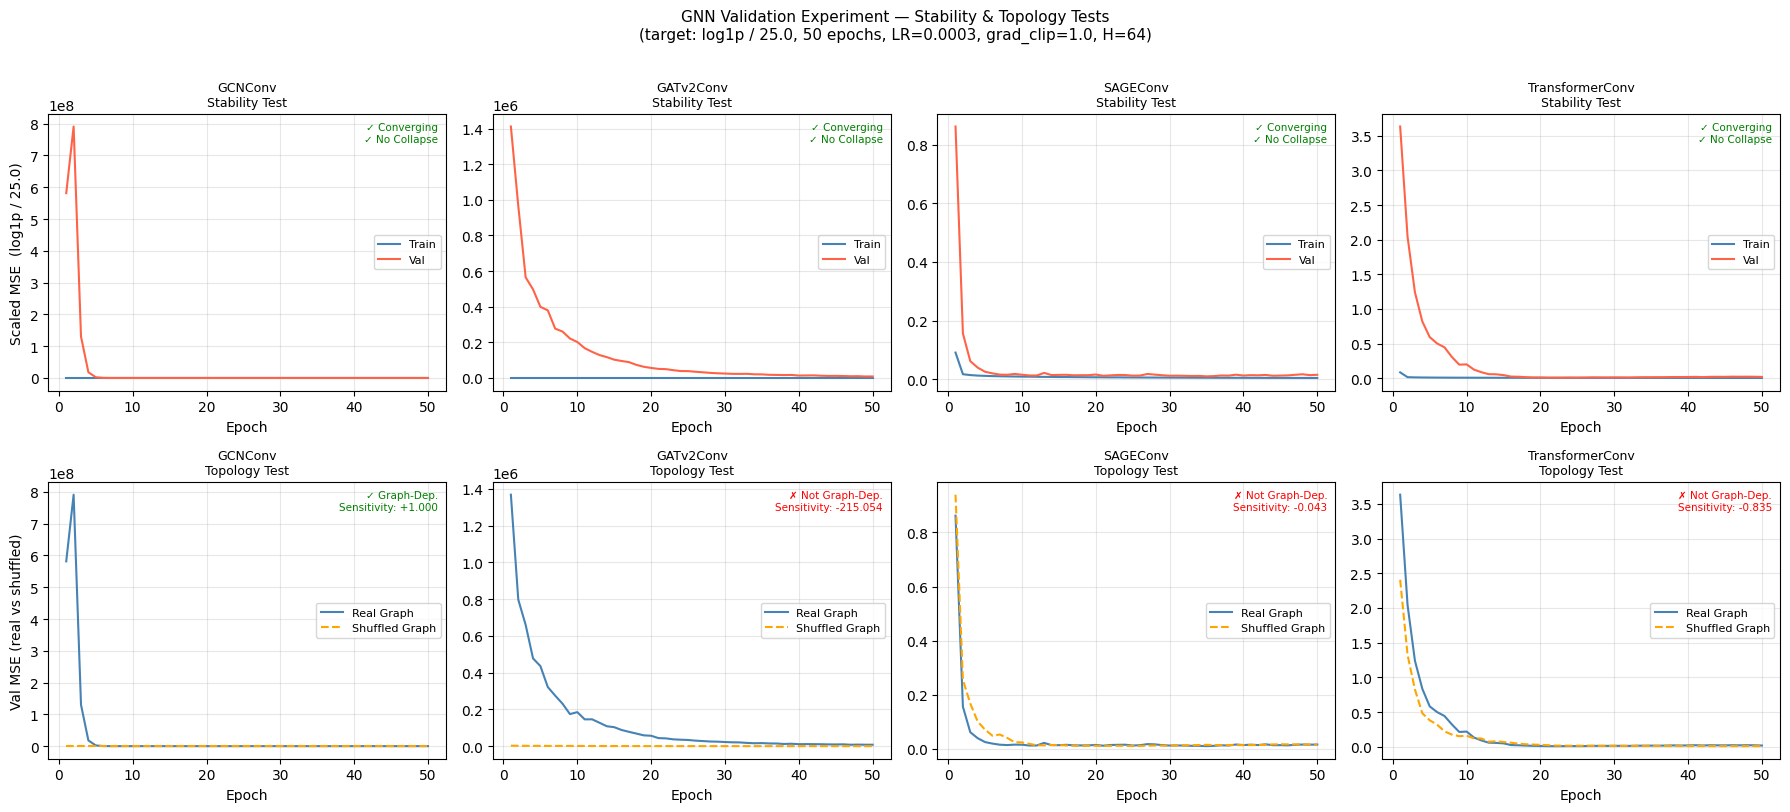

Saved: gnn_validation_experiment.png


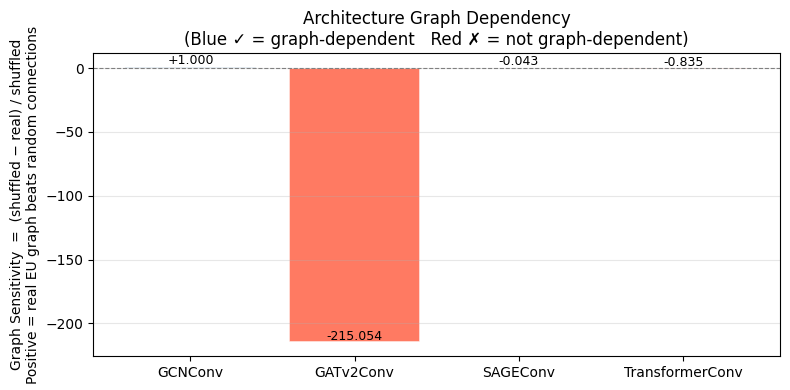

Saved: graph_sensitivity.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell I — Results Table + Visualizations
# ══════════════════════════════════════════════════════════════════════════════

# ── I.1 Summary Table ─────────────────────────────────────────────────────────
print("\n" + "═" * 95)
print("  VALIDATION EXPERIMENT SUMMARY")
print("═" * 95)
print(f"{'Architecture':<18}  {'Stable':>6}  {'No Collapse':>11}  "
      f"{'PredStd':>8}  {'RealVal':>9}  {'ShuffVal':>9}  "
      f"{'GraphSens':>10}  {'GraphDep':>9}")
print("─" * 95)

for name, r in sweep_results.items():
    print(
        f"{name:<18}  "
        f"{'✓' if r['stable'] else '✗':>6}  "
        f"{'✓' if r['not_collapsed'] else '✗':>11}  "
        f"{r['pred_std']:>8.5f}  "
        f"{r['real_final_val']:>9.5f}  "
        f"{r['shuffled_final_val']:>9.5f}  "
        f"{r['graph_sensitivity']:>+10.4f}  "
        f"{'✓' if r['graph_dependent'] else '✗':>9}"
    )

print("═" * 95)
print(f"  GraphSens = (shuffled_val − real_val) / shuffled_val\n"
      f"  Positive value → real EU graph beats random connections → architecture exploits topology")


# ── I.2 Loss Curves: Stability + Topology per architecture ────────────────────
n_archs = len(sweep_results)
fig, axes = plt.subplots(2, n_archs, figsize=(4.5 * n_archs, 8), squeeze=False)

for col, (name, r) in enumerate(sweep_results.items()):
    epochs = range(1, len(r["val_losses"]) + 1)

    # Top row — Stability test
    ax = axes[0, col]
    ax.plot(epochs, r["train_losses"], label="Train", color="steelblue", linewidth=1.5)
    ax.plot(epochs, r["val_losses"],   label="Val",   color="tomato",    linewidth=1.5)
    ax.set_title(f"{name}\nStability Test", fontsize=9)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(f"Scaled MSE  (log1p / {TARGET_SCALE})" if col == 0 else "")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    status = f"{'✓ Converging' if r['stable'] else '✗ Not Converging'}\n"\
             f"{'✓ No Collapse' if r['not_collapsed'] else '✗ Collapsed'}"
    ax.text(0.98, 0.97, status, transform=ax.transAxes,
            ha="right", va="top", fontsize=7.5,
            color="green" if (r["stable"] and r["not_collapsed"]) else "red")

    # Bottom row — Topology test
    ax2 = axes[1, col]
    ep2 = range(1, len(r["real_val_hist"]) + 1)
    ax2.plot(ep2, r["real_val_hist"],     label="Real Graph",     color="steelblue", linewidth=1.5)
    ax2.plot(ep2, r["shuffled_val_hist"], label="Shuffled Graph", color="orange",    linewidth=1.5, linestyle="--")
    ax2.set_title(f"{name}\nTopology Test", fontsize=9)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Val MSE (real vs shuffled)" if col == 0 else "")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    sens_txt = f"{'✓ Graph-Dep.' if r['graph_dependent'] else '✗ Not Graph-Dep.'}\n"\
               f"Sensitivity: {r['graph_sensitivity']:+.3f}"
    ax2.text(0.98, 0.97, sens_txt, transform=ax2.transAxes,
             ha="right", va="top", fontsize=7.5,
             color="green" if r["graph_dependent"] else "red")

plt.suptitle(
    f"GNN Validation Experiment — Stability & Topology Tests\n"
    f"(target: log1p / {TARGET_SCALE}, {N_EPOCHS} epochs, LR={LR}, grad_clip={GRAD_CLIP}, H={HIDDEN_DIM})",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig("gnn_validation_experiment.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: gnn_validation_experiment.png")


# ── I.3 Graph Sensitivity Bar Chart ───────────────────────────────────────────
fig2, ax3 = plt.subplots(figsize=(8, 4))
names         = list(sweep_results.keys())
sensitivities = [sweep_results[n]["graph_sensitivity"] for n in names]
colors        = ["steelblue" if sweep_results[n]["graph_dependent"] else "tomato" for n in names]

bars = ax3.bar(names, sensitivities, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
ax3.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax3.set_ylabel("Graph Sensitivity  =  (shuffled − real) / shuffled\n"
               "Positive = real EU graph beats random connections")
ax3.set_title(
    "Architecture Graph Dependency\n"
    "(Blue ✓ = graph-dependent   Red ✗ = not graph-dependent)"
)
ax3.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, sensitivities):
    ypos = bar.get_height() + 0.003 if val >= 0 else bar.get_height() - 0.015
    ax3.text(
        bar.get_x() + bar.get_width() / 2, ypos,
        f"{val:+.3f}", ha="center", va="bottom", fontsize=9,
    )

plt.tight_layout()
plt.savefig("graph_sensitivity.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: graph_sensitivity.png")